In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import re

In [ ]:
data = pd.read_excel('/Users/leekim/prj/RFR_Credit Risk Modeller_Candidate Case Study.xlsx', sheet_name='Data')

# EDA

In [29]:
data.head(5)

,Cus_ID,Debt restructuring history,Debt rescheduling history (reschedule),Worst credit bureau delinquency record in the past 2 years,Net Fixed Asset,Net Profit Margin (%),Sale Growth (%),Debt-to-Equity Ratio,Debt Service Coverage Area,Default Flag
0,1,No debt restructuring history,No debt rescheduling history (payment term rel...,Record found in credit bureau but no delinquen...,3.816950e+07,-113.26000,-56.14000,1.000000e+08,-0.41179,0
1,2,No debt restructuring history,No debt rescheduling history (payment term rel...,Record found in credit bureau but no delinquen...,1.678168e+07,-54.94000,-6.99000,1.000000e+08,-0.31211,0
2,3,No debt restructuring history,No debt rescheduling history (payment term rel...,Record found in credit bureau but no delinquen...,2.131518e+08,-84.12286,-46.76026,5.314100e-01,0.08560,0
3,4,No debt restructuring history,No debt rescheduling history (payment term rel...,Record found in credit bureau but no delinquen...,1.181179e+09,-80.71586,-33.07817,4.727100e-01,0.09958,0
4,5,Restructured debt with regular payments for mo...,Rescheduled debt with regular payments for mor...,Record found in credit bureau but no delinquen...,3.759797e+08,-285.69870,-84.03822,1.000000e+08,0.63897,0


In [4]:
data['Net Fixed Asset'].describe()

count    5.310000e+02
mean     2.996898e+08
std      8.965695e+08
min      1.035710e+03
25%      3.574678e+07
50%      9.052468e+07
75%      2.141620e+08
max      9.687738e+09
Name: Net Fixed Asset, dtype: float64

In [5]:
data['Net Fixed Asset'].quantile(0.95)

1392070440.3449998

In [6]:
num_cols     = ['Net Fixed Asset', 'Net Profit Margin (%)',
                'Sale Growth (%)', 'Debt-to-Equity Ratio',
                'Debt Service Coverage Area']

In [22]:
data_equity = data[data['Debt-to-Equity Ratio'].notna() & (data['Debt-to-Equity Ratio'] < data['Debt-to-Equity Ratio'].quantile(0.90))]

<Axes: xlabel='Debt-to-Equity Ratio', ylabel='Count'>

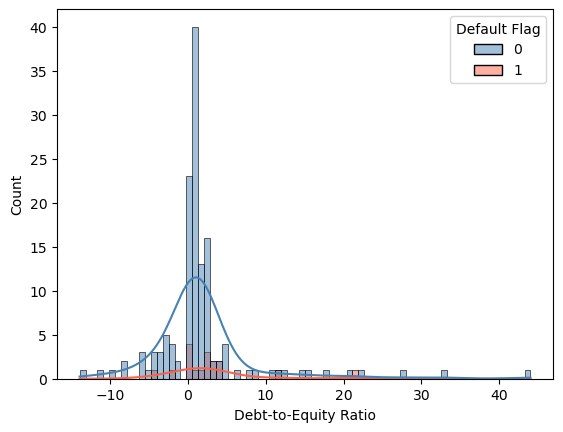

In [23]:
sns.histplot(data=data_equity, x = 'Debt-to-Equity Ratio', hue='Default Flag', kde=True, palette={0: 'steelblue', 1: 'tomato'})

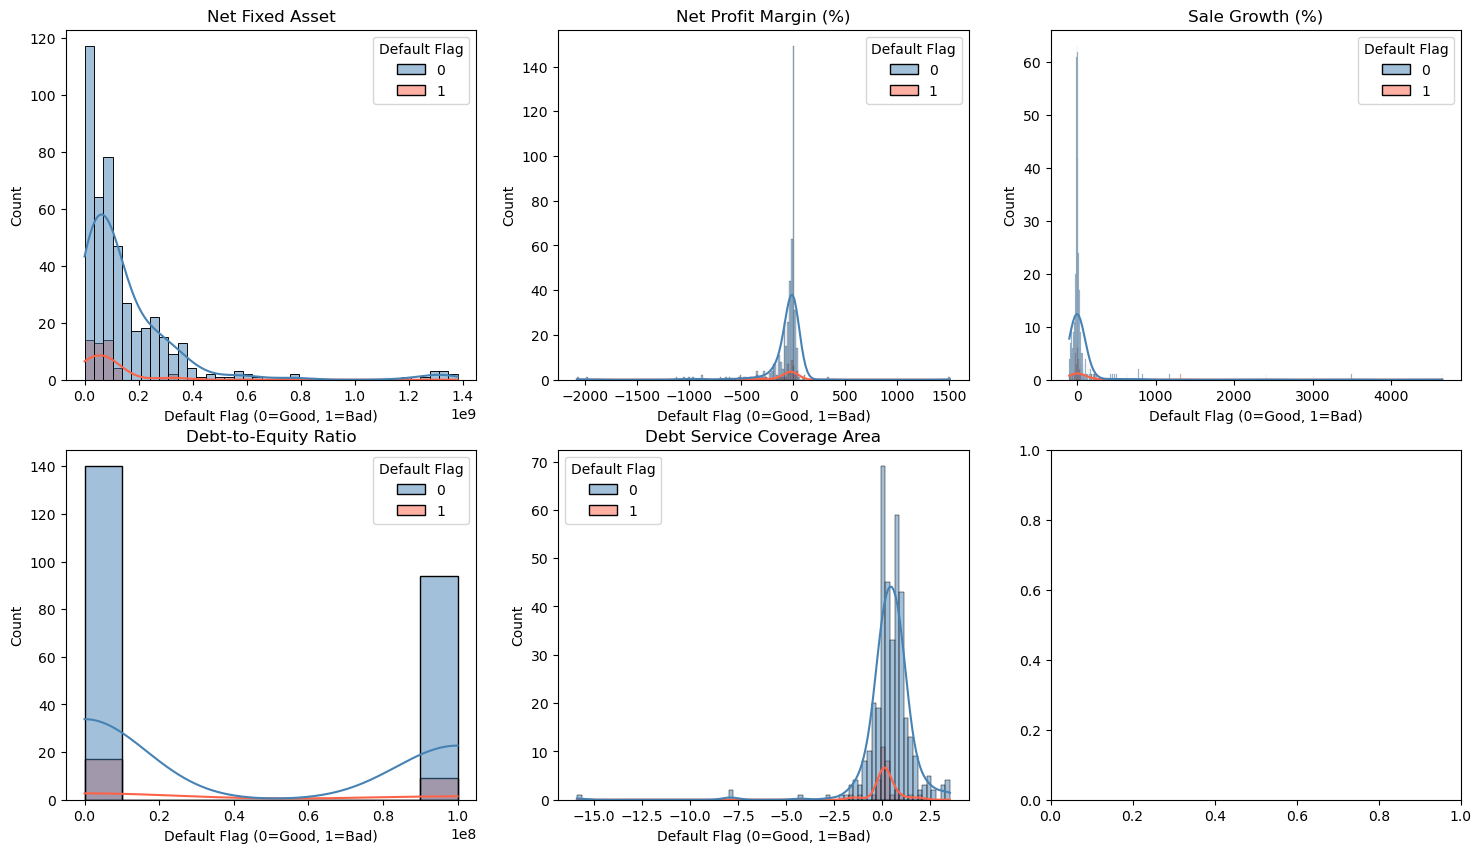

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), num_cols):
     plot_data = data[data[col].notna() &
                      (data[col] < data[col].quantile(0.95))]
     sns.histplot( x=col, data=plot_data, hue='Default Flag', kde=True,
                 palette={0: 'steelblue', 1: 'tomato'}, ax = ax)
     ax.set_title(col[:35])
     ax.set_xlabel('Default Flag (0=Good, 1=Bad)')

In [56]:
debt_structure = data.groupby(['Debt restructuring history', 'Default Flag'])['Cus_ID'].count().reset_index(name='count')


In [57]:
total = debt_structure.groupby('Debt restructuring history')['count'].sum().reset_index()
default = debt_structure[debt_structure['Default Flag'] == 1].rename(columns = {'count': 'default_count'})

In [15]:
print(f'\nSentinel values (99999998 / 99999999):')
for col in num_cols:
    for s in sentinel:
        count = (data[col] == s).sum()
        if count > 0:
            print(f'  {col}: {s} → {count} rows')


Sentinel values (99999998 / 99999999):
  Net Profit Margin (%): 99999999 → 52 rows
  Sale Growth (%): 99999999 → 68 rows
  Debt-to-Equity Ratio: 99999998 → 103 rows
  Debt-to-Equity Ratio: 99999999 → 20 rows


In [16]:
print(f'\nSkewness:')
for col in num_cols:
    print(f'  {col}: {data_clean[col].skew():.2f}')


Skewness:
  Net Fixed Asset: 6.94
  Net Profit Margin (%): -4.10
  Sale Growth (%): 10.95
  Debt-to-Equity Ratio: 2.86
  Debt Service Coverage Area: 14.45


In [17]:
data_clean['Net Fixed Asset'].describe()

count    5.310000e+02
mean     2.996898e+08
std      8.965695e+08
min      1.035710e+03
25%      3.574678e+07
50%      9.052468e+07
75%      2.141620e+08
max      9.687738e+09
Name: Net Fixed Asset, dtype: float64

In [ ]:
# ── (2) UNIVARIATE ANALYSIS ──────────────────────────────────────────────────
print('\n' + '=' * 60)
print('(1) UNIVARIATE ANALYSIS')
print('=' * 60)

# 2a. Default rate per categorical bin
for col in cat_cols:
    grp = data.groupby(col)[target].agg(['sum', 'count'])
    grp.columns = ['defaults', 'total']
    grp['default_rate'] = grp['defaults'] / grp['total']
    grp['concentration'] = grp['total'] / len(data)
    print(f'\n--- {col} ---')
    print(grp.sort_values('default_rate', ascending=False).round(4).to_string())

# 2b. Boxplots — numerical features by Default Flag
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), num_cols):
    plot_data = data_clean[data_clean[col].notna() &
                           (data_clean[col] < data_clean[col].quantile(0.95))]
    sns.boxplot(x=target, y=col, data=plot_data, ax=ax,
            palette={'0': 'steelblue', '1': 'tomato'}, log_scale=True)
        
    ax.set_title(col[:35])
    ax.set_xlabel('Default Flag (0=Good, 1=Bad)')
axes.flatten()[-1].set_visible(False)
plt.suptitle('(1) Univariate: Numerical Features by Default Flag', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_univariate_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr, ks_2samp

# ── CONFIG ────────────────────────────────────────────────────────────────────
cat_cols     = ['Debt restructuring history',
                'Debt rescheduling history (reschedule)',
                'Worst credit bureau delinquency record in the past 2 years']
num_cols     = ['Net Fixed Asset', 'Net Profit Margin (%)',
                'Sale Growth (%)', 'Debt-to-Equity Ratio',
                'Debt Service Coverage Area']
sentinel     = [99999998, 99999999]
target       = 'Default Flag'

# ── (1) DATA UNDERSTANDING & QUALITY CHECK ───────────────────────────────────
print('=' * 60)
print('(1) DATA UNDERSTANDING & QUALITY CHECK')
print('=' * 60)

print(f'\nShape: {data.shape}')
print(f'\nDtypes:\n{data.dtypes}')
print(f'\nMissing values:\n{data.isnull().sum()}')
print(f'\nDuplicate rows: {data.duplicated().sum()}')

print(f'\nClass distribution:')
print(data[target].value_counts())
print(f'Default rate: {data[target].mean():.2%}')

print(f'\nSentinel values (99999998 / 99999999):')
for col in num_cols:
    for s in sentinel:
        count = (data[col] == s).sum()
        if count > 0:
            print(f'  {col}: {s} → {count} rows')

print(f'\nNumerical Summary (excluding sentinels):')
data_clean = data.copy()
for col in num_cols:
    data_clean[col] = data_clean[col].replace(sentinel, np.nan)
print(data_clean[num_cols].describe().round(2).to_string())

print(f'\nSkewness:')
for col in num_cols:
    print(f'  {col}: {data_clean[col].skew():.2f}')

# ── (2) UNIVARIATE ANALYSIS ──────────────────────────────────────────────────
print('\n' + '=' * 60)
print('(2) UNIVARIATE ANALYSIS')
print('=' * 60)

# 2a. Default rate per categorical bin
for col in cat_cols:
    grp = data.groupby(col)[target].agg(['sum', 'count'])
    grp.columns = ['defaults', 'total']
    grp['default_rate'] = grp['defaults'] / grp['total']
    grp['concentration'] = grp['total'] / len(data)
    print(f'\n--- {col} ---')
    print(grp.sort_values('default_rate', ascending=False).round(4).to_string())

# 2b. Boxplots — numerical features by Default Flag
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), num_cols):
    plot_data = data_clean[data_clean[col].notna() &
                           (data_clean[col] < data_clean[col].quantile(0.95))]
    sns.boxplot(x=target, y=col, data=plot_data, ax=ax,
            palette={'0': 'steelblue', '1': 'tomato'})
        
    ax.set_title(col[:35])
    ax.set_xlabel('Default Flag (0=Good, 1=Bad)')
axes.flatten()[-1].set_visible(False)
plt.suptitle('(2) Univariate: Numerical Features by Default Flag', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_univariate_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# 2c. Concentration check
print('\nConcentration check (top bin % per categorical feature):')
for col in cat_cols:
    top = data[col].value_counts(normalize=True).iloc[0]
    top_label = data[col].value_counts().index[0]
    print(f'  {col[:50]}: {top:.1%} in "{top_label[:40]}"')

# ── (3) BIVARIATE ANALYSIS ───────────────────────────────────────────────────
print('\n' + '=' * 60)
print('(3) BIVARIATE ANALYSIS')
print('=' * 60)

# 3a. Point-biserial correlation + KS statistic
print('\nNumerical vs Default Flag:')
print(f'{"Feature":<35} {"Corr":>8} {"p-val":>8} {"KS":>8} {"KS p":>8}')
good = data_clean[data_clean[target] == 0]
bad  = data_clean[data_clean[target] == 1]
for col in num_cols:
    valid = data_clean[[col, target]].dropna()
    corr, p_corr = pointbiserialr(valid[target], valid[col])
    ks, p_ks = ks_2samp(
        good[col].dropna(),
        bad[col].dropna()
    )
    print(f'{col:<35} {corr:>8.3f} {p_corr:>8.4f} {ks:>8.3f} {p_ks:>8.4f}')

# 3b. Chi-square test — categorical vs default
print('\nCategorical vs Default Flag (Chi-square):')
print(f'{"Feature":<60} {"chi2":>8} {"p-val":>8} {"Sig":>5}')
for col in cat_cols:
    ct = pd.crosstab(data[col], data[target])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'{col:<60} {chi2:>8.2f} {p:>8.4f} {sig:>5}')

# 3c. Correlation heatmap — numerical features
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(data_clean[num_cols].corr(), dtype=bool))
sns.heatmap(data_clean[num_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("(3) Bivariate: Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# 3d. Cramér's V — categorical feature multicollinearity
def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print('\nCramér\'s V (categorical multicollinearity):')
short = ['C1', 'C2', 'C3']
cv_matrix = pd.DataFrame(index=short, columns=short, dtype=float)
for i, f1 in enumerate(cat_cols):
    for j, f2 in enumerate(cat_cols):
        cv_matrix.iloc[i, j] = cramers_v(data[f1], data[f2])
print(cv_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cv_matrix.astype(float), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=0, vmax=1, ax=ax)
ax.set_title("Cramér's V — Categorical Correlation", fontweight='bold')
plt.tight_layout()
plt.savefig('eda_cramers_v.png', dpi=150, bbox_inches='tight')
plt.show()

# 3e. Monotonicity — default rate per bin
data_bin_local = pd.read_excel(
    '/Users/leekim/prj/RFR_Credit Risk Modeller_Candidate Case Study.xlsx',
    sheet_name='Data_Bin')
bin_features = [c for c in data_bin_local.columns if c not in ['Cus_ID', 'Default Flag']]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, col in zip(axes.flatten(), bin_features):
    grp = data_bin_local.groupby(col)['Default Flag'].mean().reset_index()
    grp.columns = ['bin', 'default_rate']
    ax.bar(range(len(grp)), grp['default_rate'], color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp['bin'], rotation=45, ha='right', fontsize=7)
    ax.set_title(col[:30], fontsize=9)
    ax.set_ylabel('Default Rate')
    ax.axhline(data_bin_local['Default Flag'].mean(), color='red',
               linestyle='--', linewidth=0.8, label='Overall avg')
plt.suptitle('(2) Monotonicity: Default Rate per Bin', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_monotonicity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEDA complete. Saved: eda_univariate_boxplot.png, eda_correlation.png, eda_cramers_v.png, eda_monotonicity.png')


In [247]:
data_bin.columns

Index(['Cus_ID', 'Debt restructuring history',
       'Debt rescheduling history (reschedule)',
       'Worst credit bureau delinquency record in the past 2 years',
       'Net Fixed Asset', 'Net Profit Margin (%)', 'Sale Growth (%)',
       'Debt-to-Equity Ratio', 'Debt Service Coverage Area', 'Default Flag'],
      dtype='object')

In [37]:
default

,Debt restructuring history,Default Flag,default_count
2,Never restructured debt,1,21
4,No debt restructuring history,1,12
7,Restructured debt with regular payments for 6-...,1,8
9,Restructured debt with regular payments for le...,1,5
11,Restructured debt with regular payments for mo...,1,4


In [58]:
ratio_df = total.merge(default, on = 'Debt restructuring history', how = 'left')

In [59]:
ratio_df.drop(columns = 'Default Flag', inplace = True)

In [60]:
ratio_df['default_rate'] = ratio_df['default_count'] / ratio_df['count']
ratio_df['default_rate'].fillna(0, inplace = True)

/var/folders/7k/91wrm9292t3_xj_vfw85dk8w0000gn/T/ipykernel_14450/1326744496.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ratio_df['default_rate'].fillna(0, inplace = True)


In [61]:
ratio_df

,Debt restructuring history,count,default_count,default_rate
0,Credit bureau check not performed,1,NaN,0.000000
1,Never restructured debt,271,21.0,0.077491
2,No debt restructuring history,233,12.0,0.051502
3,Restructured debt in the past,10,NaN,0.000000
4,Restructured debt with regular payments for 6-12 months,18,8.0,0.444444
5,Restructured debt with regular payments for less than 6 months,8,5.0,0.625000
6,Restructured debt with regular payments for more than 12 months,16,4.0,0.250000


In [ ]:
Debt rescheduling history (reschedule)

In [62]:
debt_structure_rec = data.groupby(['Debt rescheduling history (reschedule)', 'Default Flag'])['Cus_ID'].count().reset_index(name='count')
total = debt_structure_rec.groupby('Debt rescheduling history (reschedule)')['count'].sum().reset_index()
default = debt_structure_rec[debt_structure_rec['Default Flag'] == 1].rename(columns = {'count': 'default_count'})
ratio_df_2 = total.merge(default, on = 'Debt rescheduling history (reschedule)', how = 'left')
ratio_df_2.drop(columns = 'Default Flag', inplace = True)
ratio_df_2['default_rate'] = ratio_df_2['default_count'] / ratio_df_2['count']
ratio_df_2['default_rate'].fillna(0, inplace = True)

/var/folders/7k/91wrm9292t3_xj_vfw85dk8w0000gn/T/ipykernel_14450/3436140351.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ratio_df_2['default_rate'].fillna(0, inplace = True)


In [54]:
pd.set_option('display.max_colwidth', None)

In [64]:
ratio_df_2

,Debt rescheduling history (reschedule),count,default_count,default_rate
0,No debt rescheduling history (payment term relief),185,9,0.048649
1,Rescheduled debt with regular payments for 6-12 months,27,12,0.444444
2,Rescheduled debt with regular payments for less than 6 months,30,4,0.133333
3,Rescheduled debt with regular payments for more than 12 months,33,4,0.121212


In [66]:
debt_structure_rec = data.groupby(['Worst credit bureau delinquency record in the past 2 years', 'Default Flag'])['Cus_ID'].count().reset_index(name='count')
total = debt_structure_rec.groupby('Worst credit bureau delinquency record in the past 2 years')['count'].sum().reset_index()
default = debt_structure_rec[debt_structure_rec['Default Flag'] == 1].rename(columns = {'count': 'default_count'})
ratio_df_3 = total.merge(default, on = 'Worst credit bureau delinquency record in the past 2 years', how = 'left')
ratio_df_3.drop(columns = 'Default Flag', inplace = True)
ratio_df_3['default_rate'] = ratio_df_3['default_count'] / ratio_df_3['count']
ratio_df_3['default_rate'].fillna(0, inplace = True)

/var/folders/7k/91wrm9292t3_xj_vfw85dk8w0000gn/T/ipykernel_14450/1531953751.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ratio_df_3['default_rate'].fillna(0, inplace = True)


In [68]:
ratio_df_3.sort_values('default_rate', ascending = False)


,Worst credit bureau delinquency record in the past 2 years,count,default_count,default_rate
9,Overdue more than 90 days more than 1 year ago,7,7.0,1.000000
8,Overdue 61–90 days within the past 1 year,20,6.0,0.300000
10,Overdue more than 90 days within the past 1 year,16,4.0,0.250000
6,Overdue 31–60 days within the past 1 year,29,5.0,0.172414
0,Credit bureau check not performed,6,1.0,0.166667
5,Overdue 31–60 days more than 1 year ago,18,3.0,0.166667
7,Overdue 61–90 days more than 1 year ago,7,1.0,0.142857
3,Overdue 1-30 days within the past 1 year,59,4.0,0.067797
11,Record found in credit bureau but no delinquency history,342,19.0,0.055556
1,Credit bureau check not performed (exempted),9,NaN,0.000000


In [75]:
data.columns

Index(['Cus_ID', 'Debt restructuring history',
       'Debt rescheduling history (reschedule)',
       'Worst credit bureau delinquency record in the past 2 years',
       'Net Fixed Asset', 'Net Profit Margin (%)', 'Sale Growth (%)',
       'Debt-to-Equity Ratio', 'Debt Service Coverage Area', 'Default Flag'],
      dtype='object')

<Axes: xlabel='Default Flag', ylabel='Net Fixed Asset'>

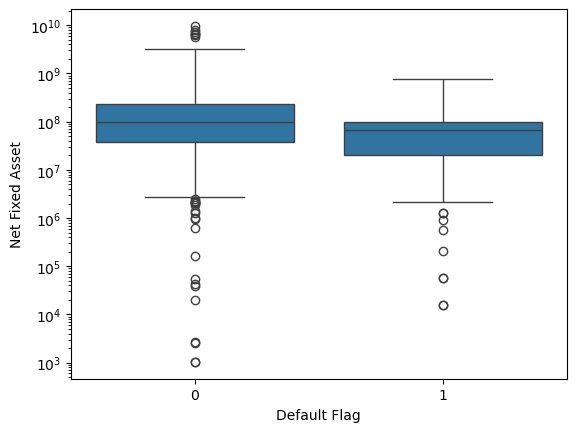

In [78]:
sns.boxplot(x = 'Default Flag', y = 'Net Fixed Asset', data = data, log_scale=True)

In [105]:
data[data['Debt-to-Equity Ratio']>= data['Debt-to-Equity Ratio'].quantile(0.90)].count()

Cus_ID                                                        123
Debt restructuring history                                    123
Debt rescheduling history (reschedule)                        110
Worst credit bureau delinquency record in the past 2 years    123
Net Fixed Asset                                               121
Net Profit Margin (%)                                         123
Sale Growth (%)                                               122
Debt-to-Equity Ratio                                          123
Debt Service Coverage Area                                    118
Default Flag                                                  123
dtype: int64

<Axes: xlabel='Net Fixed Asset', ylabel='Net Profit Margin (%)'>

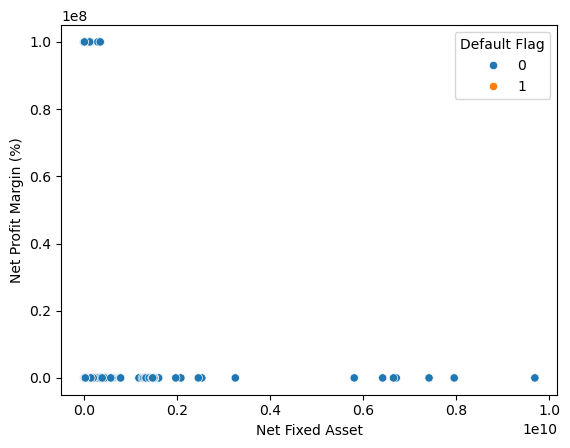

In [88]:
sns.scatterplot(x='Net Fixed Asset', y = 'Net Profit Margin (%)', hue='Default Flag', data = data)


# CALCULATE IV 

In [253]:
data_quantile = data.copy()
data_quantile = data_quantile[data_quantile['Debt-to-Equity Ratio'] < data_quantile['Debt-to-Equity Ratio'].quantile(0.90)]
data_quantile['Net Profit Margin (%)'].corr(data_quantile['Debt Service Coverage Area'])
data_quantile.count()

Cus_ID                                                        157
Debt restructuring history                                    157
Debt rescheduling history (reschedule)                        156
Worst credit bureau delinquency record in the past 2 years    157
Net Fixed Asset                                               157
Net Profit Margin (%)                                         157
Sale Growth (%)                                               154
Debt-to-Equity Ratio                                          157
Debt Service Coverage Area                                    150
Default Flag                                                  157
dtype: int64

In [ ]:
data_bin = pd.read_excel('/Users/leekim/prj/RFR_Credit Risk Modeller_Candidate Case Study.xlsx', sheet_name='Data_Bin')    

In [114]:
data_bin.head(1)

,Cus_ID,Debt restructuring history,Debt rescheduling history (reschedule),Worst credit bureau delinquency record in the past 2 years,Net Fixed Asset,Net Profit Margin (%),Sale Growth (%),Debt-to-Equity Ratio,Debt Service Coverage Area,Default Flag
0,1,No debt restructuring history,No debt rescheduling history (payment term relief),Record found in credit bureau but no delinquency history,"(0, 50000000)",<=0,<=0,99999998,<=0,0


In [158]:
total_pd = data_bin[data_bin['Default Flag'] == 1]['Debt restructuring history'].count()
total_pd

50

In [174]:
def iv_score():
    data_dict = {}
    for col in data_bin.columns:
        if col not in ['Cus_ID', 'Default Flag']:
            # print(col)
            IV = 0
            for element in data_bin[col].unique():
                dp = data_bin[(data_bin[col] == element) & (data_bin['Default Flag'] == 1)].count()[0]
                non_dp = data_bin[(data_bin[col] == element) & (data_bin['Default Flag'] == 0)].count()[0]
                total_pd = data_bin[data_bin['Default Flag'] == 1][col].count()
                total_non_pd = data_bin[data_bin['Default Flag'] == 0][col].count()
                bad_rate = dp / total_pd
                good_rate = non_dp / total_non_pd
                WoE =np.log((bad_rate + 1e-10)/ (good_rate+ 1e-10))
                if np.isinf(WoE) or np.isnan(WoE):
                    pass
                else:
                    IV_component = (bad_rate - good_rate) * WoE
                    print(f'{col} - {element} - WoE: {WoE}, IV_component: {IV_component}, dp: {dp}, non_dp: {non_dp}')
                    IV += IV_component
            data_dict[col] = IV
    return data_dict
                

In [195]:
draft_data = data_bin.groupby(['Debt restructuring history', 'Default Flag'])['Cus_ID'].count().reset_index(name='count')

In [197]:
draft_data[draft_data['Default Flag'] == 0]['count'].sum()

507

In [199]:
draft_data['ratio'] = draft_data.apply(lambda x: x['count'] / 50 if x['Default Flag'] == 1 else x['count'] / 507, axis=1)

In [204]:
draft_data

,Debt restructuring history,Default Flag,count,ratio
0,Credit bureau check not performed,0,1,0.001972
1,Never restructured debt,0,250,0.493097
2,Never restructured debt,1,21,0.420000
3,No debt restructuring history,0,221,0.435897
4,No debt restructuring history,1,12,0.240000
5,Restructured debt in the past,0,10,0.019724
6,Restructured debt with regular payments for 6-12 months,0,10,0.019724
7,Restructured debt with regular payments for 6-12 months,1,8,0.160000
8,Restructured debt with regular payments for less than 6 months,0,3,0.005917
9,Restructured debt with regular payments for less than 6 months,1,5,0.100000


In [220]:
pivot = draft_data.pivot(index = 'Debt restructuring history', columns = 'Default Flag', values = 'count').fillna(0)

In [221]:
pivot.columns = ['No Default', 'Default']
pivot.index.name = 'Debt Restructuring History'
pivot.columns.name = None

In [226]:
pivot['no_default_rate'] = pivot['No Default'] / pivot['No Default'].sum()
pivot['default_rate'] = pivot['Default'] / pivot['Default'].sum()
pivot['woe'] = np.log((pivot['default_rate'] + 1e-10) / (pivot['no_default_rate'] + 1e-10))
pivot['iv'] = (pivot['default_rate'] - pivot['no_default_rate']) * pivot['woe']

In [272]:
data_bin['Debt rescheduling history (reschedule)'].fillna('No debt rescheduling history (payment term relief)', inplace = True)


In [52]:
data_bin['Debt-to-Equity Ratio'][data_bin['Debt-to-Equity Ratio']== 99999998]=99999999

/var/folders/7k/91wrm9292t3_xj_vfw85dk8w0000gn/T/ipykernel_63487/3178544641.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_bin['Debt-to-Equity Ratio'][data_bin['Debt-to-Equity Ratio']== 99999998]=99999999
/var/folders/7k/91wrm9292t

In [237]:
draft_data = data_bin.groupby(['Debt rescheduling history (reschedule)', 'Default Flag'])['Cus_ID'].count().reset_index(name='count')

In [239]:
pivot

,Debt rescheduling history (reschedule),No Default,Default,no_default_rate,default_rate,woe,iv
0,No debt rescheduling history (payment term relief),437,30,0.861933,0.60,-0.362248,0.094885
1,Rescheduled debt with regular payments for 6-12 months,15,12,0.029586,0.24,2.093344,0.440469
2,Rescheduled debt with regular payments for less than 6 months,26,4,0.051282,0.08,0.444686,0.012770
3,Rescheduled debt with regular payments for more than 12 months,29,4,0.057199,0.08,0.335487,0.007649


In [240]:
pivot['iv'].sum()

0.5557738559273547

In [ ]:
data_filter = data_bin[~data_bin['Debt-to-Equity Ratio'].isin([99999998, 99999999])]
draft_data = data_bin.groupby(['Debt-to-Equity Ratio', 'Default Flag'])['Cus_ID'].count().reset_index(name='count')
pivot = draft_data.pivot(index = 'Debt-to-Equity Ratio', columns = 'Default Flag', values = 'count').fillna(0)
pivot.columns = ['No Default', 'Default']
pivot.index.name = 'Debt-to-Equity Ratio'
pivot.columns.name = None
pivot.reset_index(inplace = True)
pivot['no_default_rate'] = pivot['No Default'] / pivot['No Default'].sum()
pivot['default_rate'] = pivot['Default'] / pivot['Default'].sum()
pivot['woe'] = np.log((pivot['default_rate'] + 1e-10) / (pivot['no_default_rate'] + 1e-10))
pivot['iv'] = (pivot['default_rate'] - pivot['no_default_rate']) * pivot['woe']
pivot

In [32]:
total_bad  = data_bin['Default Flag'].sum()         # 50
total_good = len(data_bin) - total_bad         # 507

def calc_iv(df, feature):
    stats = df.groupby(feature)['Default Flag'].agg(['sum', 'count'])
    stats.columns = ['bad', 'total']
    stats['good']      = stats['total'] - stats['bad']
    stats['pct_bad']   = stats['bad']  / total_bad
    stats['pct_good']  = stats['good'] / total_good
    # Small epsilon avoids log(0)
    stats['woe'] = np.log((stats['pct_bad'] + 1e-10) / (stats['pct_good'] + 1e-10))
    stats['iv']  = (stats['pct_bad'] - stats['pct_good']) * stats['woe']
    stats.reset_index(inplace = True)
    return stats['iv'].sum(), stats


In [33]:
def calc_woe(df, feature):
    stats = df.groupby(feature)['Default Flag'].agg(['sum', 'count'])
    stats.columns = ['bad', 'total']
    stats['good']      = stats['total'] - stats['bad']
    stats['pct_bad']   = stats['bad']  / total_bad
    stats['pct_good']  = stats['good'] / total_good
    # Small epsilon avoids log(0)
    stats['woe'] = np.log((stats['pct_bad'] + 1e-10) / (stats['pct_good'] + 1e-10))
    stats['iv']  = (stats['pct_bad'] - stats['pct_good']) * stats['woe']
    return stats['iv'].sum()

In [53]:
calc_iv(data_bin, 'Net Fixed Asset')[1]

,Net Fixed Asset,bad,total,good,pct_bad,pct_good,woe,iv
0,"(0, 50000000)",20,165,145,0.40,0.285996,0.335487,0.038247
1,"(100000000, 150000000)",7,74,67,0.14,0.132150,0.057706,0.000453
2,"(150000000, 250000000)",0,57,57,0.00,0.112426,-20.840391,2.343003
3,"(50000000, 100000000)",18,122,104,0.36,0.205128,0.562469,0.087111
4,>250000000,4,113,109,0.08,0.214990,-0.988566,0.133447


In [35]:
weight_of_evidence = {}

In [36]:
keys = ["C1_Debt restructuring history", 
        "C2_Debt rescheduling history (reschedule)",
        "C3_Worst credit bureau delinquency record in the past 2 years",
        "F1_Net Fixed Asset", 
        "F2_Net Profit Margin (%)",
        "F3_Sale Growth (%)",
        "F4_Debt-to-Equity Ratio",
        "F5_Debt Service Coverage Area"]
values = [12.5,12.5, 25, 10, 10, 10, 10, 10 ]
weight_of_evidence = dict(zip(keys, values))
# Output: {'name': 'Bea', 'age': 28, 'role': 'Manager'}
woe_df = pd.DataFrame(weight_of_evidence.items(), columns=['Feature', 'Expert Weight'])
woe_df

,Feature,Expert Weight
0,C1_Debt restructuring history,12.5
1,C2_Debt rescheduling history (reschedule),12.5
2,C3_Worst credit bureau delinquency record in t...,25.0
3,F1_Net Fixed Asset,10.0
4,F2_Net Profit Margin (%),10.0
5,F3_Sale Growth (%),10.0
6,F4_Debt-to-Equity Ratio,10.0
7,F5_Debt Service Coverage Area,10.0


In [40]:
for col in data_bin.columns:
    if col not in ['Cus_ID', 'Default Flag'] and not re.search('fix$', col):
        iv = round(calc_iv(data_bin, col)[0], 2)
        woe_df.loc[woe_df['Feature'].str.contains(col, regex=False), 'IV'] = iv

In [42]:
def iv_classification(iv):
    if iv >= 0.3:
        return 'Strong'
    elif iv >= 0.1:
        return 'Medium'
    elif iv >= 0.02:
        return 'Weak'
    else:
        return 'Useless'

In [ ]:
# woe_df['IV-based Weight'] = round(woe_df['IV'] / woe_df['IV'].sum(), 4) * 100
# woe_df['Gap'] = woe_df['Expert Weight'] - woe_df['IV-based Weight']

In [44]:
woe_df['Ranking'] = woe_df['IV'].apply(lambda x: iv_classification(x))

In [45]:
woe_df

,Feature,Expert Weight,IV,Ranking
0,C1_Debt restructuring history,12.5,1.17,Strong
1,C2_Debt rescheduling history (reschedule),12.5,0.57,Strong
2,C3_Worst credit bureau delinquency record in t...,25.0,5.43,Strong
3,F1_Net Fixed Asset,10.0,2.60,Strong
4,F2_Net Profit Margin (%),10.0,1.28,Strong
5,F3_Sale Growth (%),10.0,0.04,Weak
6,F4_Debt-to-Equity Ratio,10.0,1.46,Strong
7,F5_Debt Service Coverage Area,10.0,1.58,Strong


In [46]:
styled = (woe_df.style
    .format({
        'Expert Weight': '{:.1f}%',
        'IV':            '{:.2f}'
    })
    #.bar(subset=['IV'], color='#7c3aed', vmin=0)
    # .apply(lambda col: [
    #     'background-color: #aaf2c9; color: #38612e' if v > 0 else
    #     'background-color: #f5bfb5; color: #065f46' if v < 0 else
    #     'background-color: #f3f4f6'
    #     for v in col], subset=['Gap'])
    .set_properties(**{'text-align': 'center', 'font-family': 'Arial', 'font-size': '13px'})
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#1e3a5f'),
            ('color', '#f0f4ff'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '10px 14px'),
            ('letter-spacing', '0.5px')
        ]},
        {'selector': 'td', 'props': [('padding', '8px 14px')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f0f4ff')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#dbeafe')]},
        {'selector': 'caption', 'props': [
            ('font-size', '15px'), ('font-weight', 'bold'),
            ('color', '#1e3a5f'), ('padding-bottom', '8px')
        ]}
    ])
    .set_caption('Feature Weight Comparison: Expert vs IV-based')
    .hide(axis='index')
)

styled


Feature,Expert Weight,IV,Ranking
C1_Debt restructuring history,12.5%,1.17,Strong
C2_Debt rescheduling history (reschedule),12.5%,0.57,Strong
C3_Worst credit bureau delinquency record in the past 2 years,25.0%,5.43,Strong
F1_Net Fixed Asset,10.0%,2.60,Strong
F2_Net Profit Margin (%),10.0%,1.28,Strong
F3_Sale Growth (%),10.0%,0.04,Weak
F4_Debt-to-Equity Ratio,10.0%,1.46,Strong
F5_Debt Service Coverage Area,10.0%,1.58,Strong


In [47]:
styled.to_html('weight_comparison.html')

In [357]:
calc_iv(data_bin, 'Debt restructuring history')

(1.1667414873236668,
                                         Debt restructuring history  bad  \
 0                                Credit bureau check not performed    0   
 1                                          Never restructured debt   21   
 2                                    No debt restructuring history   12   
 3                                    Restructured debt in the past    0   
 4          Restructured debt with regular payments for 6-12 months    8   
 5   Restructured debt with regular payments for less than 6 months    5   
 6  Restructured debt with regular payments for more than 12 months    4   
 
    total  good  pct_bad  pct_good        woe        iv  
 0      1     1     0.00  0.001972 -16.797340  0.033131  
 1    271   250     0.42  0.493097  -0.160450  0.011728  
 2    233   221     0.24  0.435897  -0.596768  0.116905  
 3     10    10     0.00  0.019724 -19.099925  0.376724  
 4     18    10     0.16  0.019724   2.093344  0.293646  
 5      8     3     0

In [54]:
df = calc_iv(data_bin, 'Debt-to-Equity Ratio')[1]
df

,Debt-to-Equity Ratio,bad,total,good,pct_bad,pct_good,woe,iv
0,99999999,12,123,111,0.24,0.218935,0.091864,0.001935
1,"(0, 0.5)",4,20,16,0.08,0.031558,0.930194,0.045060
2,"(0.5, 1)",0,31,31,0.00,0.061144,-20.231327,1.237024
3,"(1, 1.5)",1,26,25,0.02,0.049310,-0.902388,0.026449
4,"(1.5, 3)",5,25,20,0.10,0.039448,0.930194,0.056325
5,"(3, 5)",3,9,6,0.06,0.011834,1.623341,0.078189
6,<=0,2,28,26,0.04,0.051282,-0.248461,0.002803
7,>5,2,18,16,0.04,0.031558,0.237046,0.002001


In [49]:
data_input = data_bin.copy()

In [55]:
data_input['Debt-to-Equity Ratio fix'] = data_input['Debt-to-Equity Ratio'].apply(lambda x: df[df['Debt-to-Equity Ratio'] == x]['woe'].values[0] if x in df['Debt-to-Equity Ratio'].values else 0)

In [56]:
for col in data_input.columns:
    if col not in ['Cus_ID', 'Default Flag']:
        _, df = calc_iv(data_input, col)
        data_input[f'{col} fix'] = data_input[col].apply(lambda x: df[df[col]== x]['woe'].values[0] if x in df[col].values else 0)


In [57]:
data_input.head(3)

,Cus_ID,Debt restructuring history,Debt rescheduling history (reschedule),Worst credit bureau delinquency record in the past 2 years,Net Fixed Asset,Net Profit Margin (%),Sale Growth (%),Debt-to-Equity Ratio,Debt Service Coverage Area,Default Flag,Debt-to-Equity Ratio fix,Debt restructuring history fix,Debt rescheduling history (reschedule) fix,Worst credit bureau delinquency record in the past 2 years fix,Net Fixed Asset fix,Net Profit Margin (%) fix,Sale Growth (%) fix,Debt Service Coverage Area fix,Debt-to-Equity Ratio fix fix
0,1,No debt restructuring history,No debt rescheduling history (payment term rel...,Record found in credit bureau but no delinquen...,"(0, 50000000)",<=0,<=0,99999998,<=0,0,-0.029582,-0.596768,-0.656771,-0.516725,0.335487,0.24073,0.013903,-0.081407,-0.029582
1,2,No debt restructuring history,No debt rescheduling history (payment term rel...,Record found in credit bureau but no delinquen...,"(0, 50000000)",<=0,<=0,99999998,<=0,0,-0.029582,-0.596768,-0.656771,-0.516725,0.335487,0.24073,0.013903,-0.081407,-0.029582
2,3,No debt restructuring history,No debt rescheduling history (payment term rel...,Record found in credit bureau but no delinquen...,"(150000000, 250000000)",<=0,<=0,"(0.5, 1)","(0, 0.25)",0,-20.231327,-0.596768,-0.656771,-0.516725,-20.840391,0.24073,0.013903,0.803900,-20.231327


In [58]:
import re

In [63]:
list_col = [col for col in data_input.columns if re.search('fix$', col) and not re.search(r'Sale Growth \(%\)', col)]

In [64]:
list_col

['Debt-to-Equity Ratio fix',
 'Debt restructuring history fix',
 'Debt rescheduling history (reschedule) fix',
 'Worst credit bureau delinquency record in the past 2 years fix',
 'Net Fixed Asset fix',
 'Net Profit Margin (%) fix',
 'Debt Service Coverage Area fix',
 'Debt-to-Equity Ratio fix fix']

In [65]:
x = data_input[list_col]

In [119]:
x.head(3)
x.drop(columns = 'Debt-to-Equity Ratio fix fix', inplace = True)

/var/folders/7k/91wrm9292t3_xj_vfw85dk8w0000gn/T/ipykernel_63487/3061229059.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop(columns = 'Debt-to-Equity Ratio fix fix', inplace = True)


In [120]:

y = data_bin['Default Flag']


In [121]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [206]:
from sklearn.calibration import CalibratedClassifierCV

In [207]:
base_model = LogisticRegression(max_iter=1000)
model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
model.fit(x_train, y_train)

CalibratedClassifierCV(cv=5, estimator=LogisticRegression(max_iter=1000))

In [213]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [214]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

In [215]:
coef = pd.DataFrame({
    'Feature': x.columns, 
    'Coefficient': model.coef_[0], 
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Coefficient', ascending=False)

In [216]:
coef['Normalise Coefficient %'] = round(coef['Coefficient'] / coef['Coefficient'].abs().sum()*100, 2)

In [217]:
coef['Feature'] = coef['Feature'].str.replace(' fix$', '', regex=True)

In [218]:
coef

,Feature,Coefficient,Odds Ratio,Normalise Coefficient %
3,Worst credit bureau delinquency record in the ...,0.669468,1.953197,22.89
0,Debt-to-Equity Ratio,0.595495,1.813929,20.36
6,Debt Service Coverage Area,0.486423,1.626487,16.63
4,Net Fixed Asset,0.413380,1.511920,14.13
2,Debt rescheduling history (reschedule),0.351244,1.420834,12.01
1,Debt restructuring history,0.226409,1.254089,7.74
5,Net Profit Margin (%),0.182638,1.200380,6.24


In [219]:
def highlight_rows(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in df.index:
        color = 'background-color: #EBF0FA' if i % 2 == 0 else 'background-color: white'
        styles.iloc[i] = color
    return styles

styled = (coef.style 
    .apply(highlight_rows, axis=None) 
    .format({
        'Coefficient': '{:.4f}',
        'Odds Ratio': '{:.4f}',
        # 'Normalised Coefficient': '{:.4f}',
        'Normalise Coefficient %': '{:.2f}%',
        'Expert Weight %': '{:.0f}%'
    }) 
    .hide(axis='index')
    .set_caption('Logistic Regression Coefficients & Relative Feature Importance') 
    .set_table_styles([
         {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'),
                                          ('color', '#0D2B55'), ('padding-bottom', '10px'), ('text-align', 'center')]},
        {'selector': 'th', 'props': [('background-color', '#0D2B55'), ('color', 'white'),
                                     ('text-align', 'center'), ('padding', '8px 14px'),
                                      ('font-size', '13px'), ('border', 'none')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '7px 14px'),
                                     ('font-size', '13px'), ('border', 'none')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
        {'selector': 'th:first-child', 'props': [('text-align', 'left')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]},
        {'selector': 'tr', 'props': [('border', 'none')]},
    ]))
styled

Feature,Coefficient,Odds Ratio,Normalise Coefficient %
Worst credit bureau delinquency record in the past 2 years,0.6695,1.9532,22.89%
Debt-to-Equity Ratio,0.5955,1.8139,20.36%
Debt Service Coverage Area,0.4864,1.6265,16.63%
Net Fixed Asset,0.4134,1.5119,14.13%
Debt rescheduling history (reschedule),0.3512,1.4208,12.01%
Debt restructuring history,0.2264,1.2541,7.74%
Net Profit Margin (%),0.1826,1.2004,6.24%


In [220]:
expert_weights = {
    'Worst credit bureau delinquency record in the past 2 years': 25,
    'Debt rescheduling history (reschedule)': 12.5,
    'Debt restructuring history': 12.5,
    'Net Fixed Asset': 10,
    'Net Profit Margin (%)': 10,
    'Sale Growth (%)': 10,
    'Debt-to-Equity Ratio': 10,
    'Debt Service Coverage Area': 10,
}
coef['Expert Weight %'] = coef['Feature'].map(expert_weights)


In [221]:
coef

,Feature,Coefficient,Odds Ratio,Normalise Coefficient %,Expert Weight %
3,Worst credit bureau delinquency record in the ...,0.669468,1.953197,22.89,25.0
0,Debt-to-Equity Ratio,0.595495,1.813929,20.36,10.0
6,Debt Service Coverage Area,0.486423,1.626487,16.63,10.0
4,Net Fixed Asset,0.413380,1.511920,14.13,10.0
2,Debt rescheduling history (reschedule),0.351244,1.420834,12.01,12.5
1,Debt restructuring history,0.226409,1.254089,7.74,12.5
5,Net Profit Margin (%),0.182638,1.200380,6.24,10.0


In [222]:
styled.to_html('weight_comparison_logistic.html')

In [223]:
print(coef.columns.tolist())

['Feature', 'Coefficient', 'Odds Ratio', 'Normalise Coefficient %', 'Expert Weight %']


In [224]:
styled = (coef.style 
    .format({
        'Coefficient': '{:.4f}',
        'Odds Ratio': '{:.4f}',
        'Normalised Coefficient': '{:.4f}',
        'Normalised Coefficient %': '{:.2f}%'
    }) 
    #.background_gradient(subset=['Normalised Coefficient %'], cmap='Blues') 
    #.bar(subset=['Odds Ratio'], color='#90CAF9', vmin=1) 
    .set_properties(**{'text-align': 'right'}) 
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#0D2B55'), ('color', 'white'), ('text-align', 'center')]
    }])
)
styled

,Feature,Coefficient,Odds Ratio,Normalise Coefficient %,Expert Weight %
3,Worst credit bureau delinquency record in the past 2 years,0.6695,1.9532,22.890000,25.000000
0,Debt-to-Equity Ratio,0.5955,1.8139,20.360000,10.000000
6,Debt Service Coverage Area,0.4864,1.6265,16.630000,10.000000
4,Net Fixed Asset,0.4134,1.5119,14.130000,10.000000
2,Debt rescheduling history (reschedule),0.3512,1.4208,12.010000,12.500000
1,Debt restructuring history,0.2264,1.2541,7.740000,12.500000
5,Net Profit Margin (%),0.1826,1.2004,6.240000,10.000000


In [225]:
woe_cols

['Debt-to-Equity Ratio fix',
 'Debt restructuring history fix',
 'Debt rescheduling history (reschedule) fix',
 'Worst credit bureau delinquency record in the past 2 years fix',
 'Net Fixed Asset fix',
 'Net Profit Margin (%) fix',
 'Debt Service Coverage Area fix']

In [226]:
woe_cols = [col for col in data_input.columns if col.endswith('fix') and col not in  ['Debt-to-Equity Ratio fix fix', 'Sale Growth (%) fix']]

In [227]:
model.coef_

array([[0.59549497, 0.22640937, 0.35124397, 0.6694677 , 0.41338018,
        0.18263828, 0.48642278]])

In [228]:
# PDO parameters
PDO        = 20
base_score = 600
base_odds  = 50

factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)



# WoE columns
woe_cols = [col for col in data_input.columns if col.endswith('fix') and col not in  ['Debt-to-Equity Ratio fix fix', 'Sale Growth (%) fix']]
feature_names = [col.replace(' fix', '') for col in woe_cols]

# Per-feature points
for i, col in enumerate(woe_cols):
    pts_col = col.replace('fix', 'pts')
    data_input[pts_col] = -(factor * model.coef_[0][i]) * data_input[col]

# Total score
pts_cols = [col for col in data_input.columns if col.endswith('pts')]
data_input['score'] = offset + (factor * model.intercept_[0]) + data_input[pts_cols].sum(axis=1)

data_input[['Cus_ID', 'Default Flag', 'score'] + pts_cols].head(10)


,Cus_ID,Default Flag,score,Debt-to-Equity Ratio pts,Debt restructuring history pts,Debt rescheduling history (reschedule) pts,Worst credit bureau delinquency record in the past 2 years pts,Net Fixed Asset pts,Net Profit Margin (%) pts,Sale Growth (%) pts,Debt Service Coverage Area pts
0,1,0,446.999966,0.508292,3.898562,6.656220,9.981457,-4.001559,-1.268604,-0.218499,1.142567
1,2,0,446.999966,0.508292,3.898562,6.656220,9.981457,-4.001559,-1.268604,-0.218499,1.142567
2,3,0,1034.266063,347.621801,3.898562,6.656220,9.981457,248.576488,-1.268604,-0.218499,-11.282892
3,4,0,433.876104,-15.982915,3.898562,6.656220,9.981457,11.791244,-1.268604,-0.218499,-11.282892
4,5,0,462.410793,0.508292,-7.956131,-3.400075,9.981457,11.791244,-1.268604,-0.218499,22.671578
5,6,0,444.292604,0.508292,3.898562,6.656220,9.981457,-6.708921,-1.268604,-0.218499,1.142567
6,7,0,727.004035,347.621801,-13.675387,-21.215541,-23.525406,11.791244,-1.268604,-4.168169,1.142567
7,8,0,567.106657,15.505146,3.898562,-21.215541,9.981457,11.791244,106.264136,-4.168169,14.748292
8,9,0,424.518212,0.508292,3.898562,-3.400075,9.981457,-4.001559,-1.268604,-0.218499,-11.282892
9,10,0,461.996820,15.505146,3.898562,6.656220,9.981457,-4.001559,-1.268604,-0.218499,1.142567


In [229]:
data_input['score_scaled'].describe()

count    557.000000
mean     542.807899
std       70.461179
min      300.000000
25%      507.000000
50%      513.000000
75%      564.000000
max      850.000000
Name: score_scaled, dtype: float64

In [230]:
data_input['default_prob'] = model.predict_proba(x)[:, 1]

In [231]:
data_input['score_band'] = pd.qcut(data_input['score_scaled'], q=10)
data_input.groupby('score_band', observed=True).agg(
    Count=('score', 'count'),
    Defaults=('Default Flag', 'sum'),
    Default_Rate=('Default Flag', 'mean')
).assign(Default_Rate=lambda x: x['Default_Rate'].map('{:.2%}'.format))

,Count,Defaults,Default_Rate
score_band,,,
"(299.999, 498.0]",58,26,44.83%
"(498.0, 505.0]",63,8,12.70%
"(505.0, 508.0]",63,6,9.52%
"(508.0, 510.0]",56,3,5.36%
"(510.0, 513.0]",50,5,10.00%
"(513.0, 517.0]",45,0,0.00%
"(517.0, 549.0]",57,2,3.51%
"(549.0, 579.0]",55,0,0.00%
"(579.0, 667.0]",61,0,0.00%


In [232]:
data_input['score_band'] = pd.qcut(data_input['score_scaled'], q=10)
data_input.groupby('score_band', observed=True).agg(
    Count=('score', 'count'),
    Defaults=('Default Flag', 'sum'),
    Default_Rate=('Default Flag', 'mean')
).assign(Default_Rate=lambda x: x['Default_Rate'].map('{:.2%}'.format))


,Count,Defaults,Default_Rate
score_band,,,
"(299.999, 498.0]",58,26,44.83%
"(498.0, 505.0]",63,8,12.70%
"(505.0, 508.0]",63,6,9.52%
"(508.0, 510.0]",56,3,5.36%
"(510.0, 513.0]",50,5,10.00%
"(513.0, 517.0]",45,0,0.00%
"(517.0, 549.0]",57,2,3.51%
"(549.0, 579.0]",55,0,0.00%
"(579.0, 667.0]",61,0,0.00%


In [233]:
band_table = data_input.groupby('score_band', observed=True).agg(
    Count=('score', 'count'),
    Defaults=('Default Flag', 'sum'),
    Default_Rate=('Default Flag', 'mean')
).reset_index()

def highlight_rows(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in df.index:
        color = 'background-color: #EBF0FA' if i % 2 == 0 else 'background-color: white'
        styles.iloc[i] = color
    return styles

def color_default_rate(val):
    if val >= 0.20:
        return 'color: #C0392B; font-weight: bold'
    elif val >= 0.10:
        return 'color: #E67E22; font-weight: bold'
    elif val > 0:
        return 'color: #2980B9'
    return 'color: #27AE60'

styled = (band_table.style 
    .apply(highlight_rows, axis=None) 
    .format({
        'Count': '{:,}',
        'Defaults': '{:,}',
        'Default_Rate': '{:.2%}'
    }) 
    # .applymap(color_default_rate, subset=['Default_Rate']) 
    .hide(axis='index') 
    .set_caption('Score Band Distribution & Default Rate') 
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'),
                                          ('color', '#0D2B55'), ('padding-bottom', '10px'), ('text-align', 'center')]},
        {'selector': 'th', 'props': [('background-color', '#0D2B55'), ('color', 'white'),
                                     ('text-align', 'center'), ('padding', '8px 14px'),
                                     ('font-size', '13px'), ('border', 'none')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '7px 14px'),
                                     ('font-size', '13px'), ('border', 'none')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
        {'selector': 'th:first-child', 'props': [('text-align', 'left')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]},
    ])
)
styled

score_band,Count,Defaults,Default_Rate
"(299.999, 498.0]",58,26,44.83%
"(498.0, 505.0]",63,8,12.70%
"(505.0, 508.0]",63,6,9.52%
"(508.0, 510.0]",56,3,5.36%
"(510.0, 513.0]",50,5,10.00%
"(513.0, 517.0]",45,0,0.00%
"(517.0, 549.0]",57,2,3.51%
"(549.0, 579.0]",55,0,0.00%
"(579.0, 667.0]",61,0,0.00%
"(667.0, 850.0]",49,0,0.00%


In [234]:
styled.to_html('score_band_distribution.html')

In [235]:
score_min = data_input['score'].min()
score_max = data_input['score'].max()

target_min, target_max = 300, 850

data_input['score_scaled'] = (
    (data_input['score'] - score_min) / (score_max - score_min)
) * (target_max - target_min) + target_min

data_input['score_scaled'] = data_input['score_scaled'].round(0).astype(int)

In [236]:
# Build bin-score mapping for each feature
records = []

for i, col in enumerate(woe_cols):
    feature = col.replace(' fix', '')
    
    # Get unique bins and their WoE values
    bin_woe = data_input[[feature, col]].drop_duplicates().rename(columns={col: 'woe'})
    bin_woe['feature']   = feature
    bin_woe['score_pts'] = -(factor * model.coef_[0][i]) * bin_woe['woe']
    bin_woe = bin_woe.rename(columns={feature: 'bin'})
    
    records.append(bin_woe[['feature', 'bin', 'woe', 'score_pts']])

scorecard = pd.concat(records, ignore_index=True).sort_values(['feature', 'score_pts'], ascending=[True, False])
scorecard['score_pts'] = scorecard['score_pts'].round(2)
scorecard['woe']       = scorecard['woe'].round(4)

scorecard



,feature,bin,woe,score_pts
55,Debt Service Coverage Area,"(1, 1.2)",-20.1295,282.52
49,Debt Service Coverage Area,"(0.5, 0.75)",-1.6153,22.67
54,Debt Service Coverage Area,>2,-1.3724,19.26
51,Debt Service Coverage Area,"(1.2, 2)",-1.1492,16.13
50,Debt Service Coverage Area,"(0.75, 1)",-1.0508,14.75
47,Debt Service Coverage Area,<=0,-0.0814,1.14
53,Debt Service Coverage Area,NaN,0.0000,-0.00
52,Debt Service Coverage Area,"(0.25, 0.5)",0.3424,-4.81
48,Debt Service Coverage Area,"(0, 0.25)",0.8039,-11.28
17,Debt rescheduling history (reschedule),No debt rescheduling history (payment term rel...,-0.6568,6.66


In [237]:
print(f'Factor : {factor:.4f}')
print(f'Offset : {offset:.4f}')
print(f'Intercept contribution: {factor * model.intercept_[0]:.4f}')
print()
print('Score distribution:')
print(data_input.groupby('Default Flag')['score'].describe().round(1))


Factor : 28.8539
Offset : 487.1229
Intercept contribution: -56.8213

Score distribution:
              count   mean    std    min    25%    50%    75%     max
Default Flag                                                         
0             507.0  554.9  177.6  365.3  434.5  455.7  695.2  1292.9
1              50.0  350.9  158.4  -58.8  370.8  412.5  432.5   472.4


## III. VALIDATION

In [238]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Detailed metrics
print(classification_report(y_test, y_pred))

# AUC-ROC Score
print('AUC-ROC:', roc_auc_score(y_test, y_prob))

[[101   1]
 [  4   6]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       102
           1       0.86      0.60      0.71        10

    accuracy                           0.96       112
   macro avg       0.91      0.80      0.84       112
weighted avg       0.95      0.96      0.95       112

AUC-ROC: 0.9029411764705882


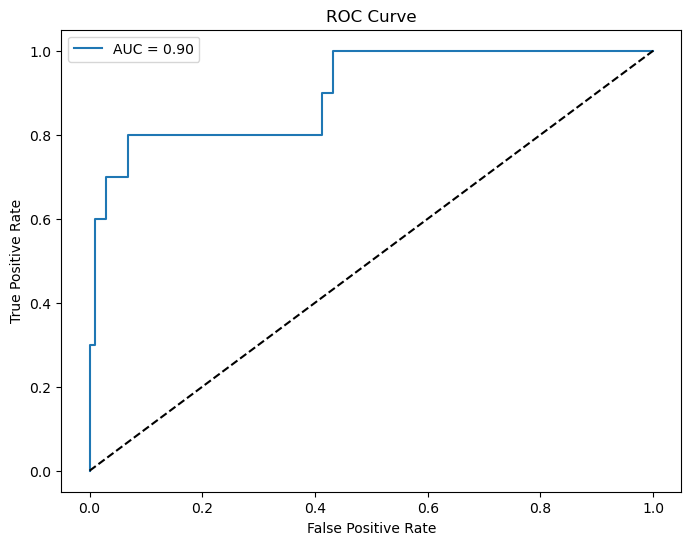

In [239]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [240]:
y_prob.size

112

In [245]:
def hosmer_lemeshow_test(y_true, y_prob, score_band):
    df = pd.DataFrame({'y': y_true, 'prob': y_prob, 'band': score_band})
    
    grouped = df.groupby('band', observed=True).agg(
        Observed_1=('y', 'sum'),
        Total=('y', 'count'),
        Expected_1=('prob', 'sum')
    )
    grouped['Observed_0'] = grouped['Total'] - grouped['Observed_1']
    grouped['Expected_0'] = grouped['Total'] - grouped['Expected_1']
    
    hl_stat = (
        ((grouped['Observed_1'] - grouped['Expected_1']) ** 2 / grouped['Expected_1']) +
        ((grouped['Observed_0'] - grouped['Expected_0']) ** 2 / grouped['Expected_0'])
    ).sum()
    
    dof = len(grouped) - 2
    p_value = 1 - stats.chi2.cdf(hl_stat, df=dof)
    
    print(f"Groups:                    {len(grouped)}")
    print(f"Hosmer-Lemeshow Statistic: {hl_stat:.4f}")
    print(f"Degrees of Freedom:        {dof}")
    print(f"P-value:                   {p_value:.4f}")
    print()
    if p_value > 0.05:
        print("Good fit — fail to reject H0")
    else:
        print("Poor fit — reject H0")
    
    return grouped

hl_table = hosmer_lemeshow_test(
    data_input['Default Flag'],
    data_input['default_prob'],
    data_input['score_band']
)
hl_table


Groups:                    10
Hosmer-Lemeshow Statistic: 4.8454
Degrees of Freedom:        8
P-value:                   0.7740

Good fit — fail to reject H0


,Observed_1,Total,Expected_1,Observed_0,Expected_0
band,,,,,
"(299.999, 498.0]",26,58,24.169378,32,33.830622
"(498.0, 505.0]",8,63,9.576719,55,53.423281
"(505.0, 508.0]",6,63,6.656772,57,56.343228
"(508.0, 510.0]",3,56,5.342941,53,50.657059
"(510.0, 513.0]",5,50,3.601874,45,46.398126
"(513.0, 517.0]",0,45,2.184918,45,42.815082
"(517.0, 549.0]",2,57,1.467295,55,55.532705
"(549.0, 579.0]",0,55,0.013453,55,54.986547
"(579.0, 667.0]",0,61,0.000145,61,60.999855


In [246]:
# def highlight_rows(df):
#     styles = pd.DataFrame('', index=df.index, columns=df.columns)
#     for i in range(len(df)):
#         color = 'background-color: #EBF0FA' if i % 2 == 0 else 'background-color: white'
#         styles.iloc[i] = color
#     return styles

styled = (hl_table.reset_index().style 
    .apply(highlight_rows, axis=None) 
    .format({
        'Observed_1': '{:.0f}',
        'Observed_0': '{:.0f}',
        
        'Expected_1': '{:.2f}',
        'Expected_0': '{:.2f}',
        'Total':      '{:.0f}'
    }) 
    .hide(axis='index') 
    .set_caption('Hosmer-Lemeshow Test: Observed vs Expected by Score Band') 
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'),
                                          ('color', '#0D2B55'), ('padding-bottom', '10px'), ('text-align', 'center')]},
        {'selector': 'th', 'props': [('background-color', '#0D2B55'), ('color', 'white'),
                                     ('text-align', 'center'), ('padding', '8px 14px'),
                                     ('font-size', '13px'), ('border', 'none')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '7px 14px'),
                                     ('font-size', '13px'), ('border', 'none')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
        {'selector': 'th:first-child', 'props': [('text-align', 'left')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]},
    ])
)
styled


band,Observed_1,Total,Expected_1,Observed_0,Expected_0
"(299.999, 498.0]",26,58,24.17,32,33.83
"(498.0, 505.0]",8,63,9.58,55,53.42
"(505.0, 508.0]",6,63,6.66,57,56.34
"(508.0, 510.0]",3,56,5.34,53,50.66
"(510.0, 513.0]",5,50,3.60,45,46.40
"(513.0, 517.0]",0,45,2.18,45,42.82
"(517.0, 549.0]",2,57,1.47,55,55.53
"(549.0, 579.0]",0,55,0.01,55,54.99
"(579.0, 667.0]",0,61,0.00,61,61.00
"(667.0, 850.0]",0,49,0.00,49,49.00


In [243]:
styled.to_html('Hosmer-Lemeshow Test.html')

In [244]:
from scipy.stats import binomtest

total_defaults = data_input['Default Flag'].sum()
total_n = len(data_input)
avg_pd = data_input['default_prob'].mean()

result = binomtest(total_defaults, total_n, avg_pd, alternative='two-sided')

print(f"Observed Defaults:   {total_defaults}")
print(f"Total Borrowers:     {total_n}")
print(f"Expected PD (avg):   {avg_pd:.4f}")
print(f"Expected Defaults:   {avg_pd * total_n:.1f}")
print(f"p-value:             {result.pvalue:.4f}")
print()
if result.pvalue > 0.05:
    print("Fail to reject H0 — predicted default rate matches observed")
else:
    print("Reject H0 — predicted default rate significantly differs from observed")


Observed Defaults:   50
Total Borrowers:     557
Expected PD (avg):   0.0952
Expected Defaults:   53.0
p-value:             0.7182

Fail to reject H0 — predicted default rate matches observed
